In [ ]:
#Import Statements
import os, copy, json, time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix
from google.colab import drive

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

drive.mount('/content/drive')
CHECKPOINT_DIR = "/content/drive/MyDrive/AML_Dataset/checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
CONFIG_NAME = "dinov2_frozenFalse_weightsFalse"
CHECKPOINT_PATH = f"{CHECKPOINT_DIR}/{CONFIG_NAME}_checkpoint.pth"

!pip install grad-cam -q

Using device: cuda
Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 46.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:

from google.colab import files
uploaded = files.upload()

import zipfile
with zipfile.ZipFile("WaRP-C-preprocessed.zip", "r") as z:
    z.extractall("/content/WaRP-C-preprocessed")

Saving WaRP-C-preprocessed.zip to WaRP-C-preprocessed.zip


In [ ]:
PREPROCESSED_ROOT = "/content/WaRP-C-preprocessed"
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

CFG = {
    "num_classes":28,
    "backbone_name":"dinov2_vitb14",
    "freeze_backbone": False,
    "use_class_weights":False,
    "lr":3e-4,
    "min_lr": 1e-6,
    "weight_decay":0.05,
    "label_smoothing":0.1,
    "warmup_epochs":3,
    "num_epochs":15,
    "blend_alpha":0.4,
    "early_stop_patience":5,
}

#Transforms
full_train_pipeline = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.6, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3, hue=0.1),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.2)),
])

eval_pipeline = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

In [ ]:
#Create Dataset and dataloaders
def _make_flat_dataset(root_dir, transform):
    samples, class_to_idx = [], {}
    for superclass in sorted(os.listdir(root_dir)):
        sp = os.path.join(root_dir, superclass)
        if not os.path.isdir(sp): continue
        for subclass in sorted(os.listdir(sp)):
            scp = os.path.join(sp, subclass)
            if not os.path.isdir(scp): continue
            if subclass not in class_to_idx:
                class_to_idx[subclass] = len(class_to_idx)
            for img_name in os.listdir(scp):
                if img_name.lower().endswith(".jpg"):
                    samples.append((os.path.join(scp, img_name), class_to_idx[subclass]))
    dataset = datasets.ImageFolder(root_dir, transform=transform)
    dataset.samples = dataset.imgs = samples
    dataset.targets = [s[1] for s in samples]
    dataset.classes = list(class_to_idx.keys())
    dataset.class_to_idx = class_to_idx
    return dataset


def get_dataloaders(root=PREPROCESSED_ROOT, batch_size=32, num_workers=2, seed=42):
    torch.manual_seed(seed)
    train_ds = _make_flat_dataset(f"{root}/train", transform=full_train_pipeline)
    val_ds= _make_flat_dataset(f"{root}/val",   transform=eval_pipeline)
    test_ds= _make_flat_dataset(f"{root}/test",  transform=eval_pipeline)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                               num_workers=num_workers, pin_memory=True, drop_last=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False,
                               num_workers=num_workers, pin_memory=True)
    test_loader= DataLoader(test_ds, batch_size=batch_size, shuffle=False,
                               num_workers=num_workers, pin_memory=True)
    return train_loader, val_loader, test_loader, train_ds, val_ds, test_ds


def get_class_counts(dataset):
    counts = np.bincount(dataset.targets, minlength=len(dataset.classes))
    return counts.astype(np.float32)


train_loader, val_loader, test_loader, train_ds, val_ds, test_ds = get_dataloaders()
num_classes = len(train_loader.dataset.classes)
class_names = train_loader.dataset.classes
print(f"Classes: {num_classes} | Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

Classes: 28 | Train: 7058 | Val: 1765 | Test: 1551


In [ ]:
#Classifier model
# Wraps DINOv2's pretrained backbone with a new linear head for 28-class output.
class DINOv2Classifier(nn.Module):
    def __init__(self, backbone, embed_dim, num_classes, freeze_backbone=False):
        super().__init__()
        self.backbone = backbone
        self.head = nn.Linear(embed_dim, num_classes)
        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False

    def forward(self, x):
        features = self.backbone(x)
        return self.head(features)


backbone = torch.hub.load('facebookresearch/dinov2', CFG["backbone_name"])
embed_dim = backbone.embed_dim
model = DINOv2Classifier(backbone, embed_dim, num_classes, freeze_backbone=CFG["freeze_backbone"]).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {total_params:,} | Trainable: {trainable:,}")

Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vitb14/dinov2_vitb14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vitb14_pretrain.pth


100%|██████████| 330M/330M [00:02<00:00, 171MB/s]


Total params: 86,602,012 | Trainable: 86,602,012


In [ ]:
if CFG["use_class_weights"]:
    samples_per_class = get_class_counts(train_ds)
    freq_inverse = 1.0 / (samples_per_class + 1e-6)
    loss_weights = torch.tensor(freq_inverse / freq_inverse.sum(), dtype=torch.float).to(device)
    criterion = nn.CrossEntropyLoss(weight=loss_weights, label_smoothing=CFG["label_smoothing"])
else:
    criterion = nn.CrossEntropyLoss(label_smoothing=CFG["label_smoothing"])

if CFG["freeze_backbone"]:
    optimizer = optim.AdamW(model.head.parameters(), lr=CFG["lr"], weight_decay=CFG["weight_decay"])
else:
    optimizer = optim.AdamW([
        {"params": model.backbone.parameters(), "lr": CFG["lr"] / 10},
        {"params": model.head.parameters(), "lr": CFG["lr"]},
    ], weight_decay=CFG["weight_decay"])

def get_lr_scale(epoch):
    if epoch < CFG["warmup_epochs"]:
        return (epoch + 1) / CFG["warmup_epochs"]
    decay_progress = (epoch - CFG["warmup_epochs"]) / max(1, CFG["num_epochs"] - CFG["warmup_epochs"])
    return CFG["min_lr"] / CFG["lr"] + 0.5 * (1 - CFG["min_lr"] / CFG["lr"]) * (1 + np.cos(np.pi * decay_progress))

scheduler = optim.lr_scheduler.LambdaLR(optimizer, get_lr_scale)

In [ ]:
#mixup_data / mixup_criterion: blend pairs of images and labels together
#and compute a correspondingly blended loss, as an augmentation/
#regularisation technique.
def mixup_data(x, y, alpha=1.0):
    blend_ratio = np.random.beta(alpha, alpha) if alpha > 0 else 1
    index = torch.randperm(x.size(0)).to(x.device)
    blended_imgs = blend_ratio * x + (1 - blend_ratio) * x[index, :]
    return blended_imgs, y, y[index], blend_ratio

def mixup_criterion(criterion, pred, labels_orig, labels_mixed, blend_ratio):
    return blend_ratio * criterion(pred, labels_orig) + (1 - blend_ratio) * criterion(pred, labels_mixed)

def train_one_epoch(model, loader, optimizer, criterion, blend_alpha=0.0):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        if blend_alpha > 0:
            imgs, labels_orig, labels_mixed, blend_ratio = mixup_data(imgs, labels, blend_alpha)
        optimizer.zero_grad()
        logits = model(imgs)
        loss = mixup_criterion(criterion, logits, labels_orig, labels_mixed, blend_ratio) if blend_alpha > 0 else criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += imgs.size(0)
    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, eval_device=None):
    eval_device = eval_device or device
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(eval_device), labels.to(eval_device)
        logits = model(imgs)
        loss = criterion(logits, labels)
        running_loss += loss.item() * imgs.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += imgs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return running_loss / total, correct / total, all_preds, all_labels

In [ ]:
#Training
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_acc, patience_counter, start_epoch = 0.0, 0, 0

if os.path.exists(CHECKPOINT_PATH):
    ckpt = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
    model.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optimizer_state"])
    scheduler.load_state_dict(ckpt["scheduler_state"])
    start_epoch = ckpt["epoch"] + 1
    best_val_acc = ckpt["best_val_acc"]
    patience_counter = ckpt["patience_counter"]
    history = ckpt["history"]

best_state = copy.deepcopy(model.state_dict())

for epoch in range(start_epoch, CFG["num_epochs"]):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, blend_alpha=CFG["blend_alpha"])
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion)
    scheduler.step()

    epoch_lr = optimizer.param_groups[0]["lr"]
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Epoch [{epoch+1:02d}/{CFG['num_epochs']}] "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.3f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.3f} | LR: {epoch_lr:.2e}")

    improved = val_acc > best_val_acc
    if improved:
        best_val_acc = val_acc
        best_state = copy.deepcopy(model.state_dict())
        patience_counter = 0
        print(f"  New best val acc: {best_val_acc:.4f}")
    else:
        patience_counter += 1

    torch.save({
        "epoch": epoch,
        "model_state": model.state_dict(),
        "best_model_state": best_state,
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "best_val_acc": best_val_acc,
        "patience_counter": patience_counter,
        "history": history,
        "cfg": CFG,
    }, CHECKPOINT_PATH)

    if patience_counter >= CFG["early_stop_patience"]:
        print("Early stopping triggered.")
        break

model.load_state_dict(best_state)
print(f"\nBest val accuracy: {best_val_acc:.4f}")


Best val accuracy: 0.8425


In [ ]:
# Final test evaluation
test_loss, test_acc, test_preds, test_labels = evaluate(model, test_loader, criterion)
precision, recall, f1, _ = precision_recall_fscore_support(test_labels, test_preds, average="weighted", zero_division=0)

print(f"\nDINOv2 (fine-tuned, unweighted) Test Results")
print(f"Accuracy : {test_acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

cm = confusion_matrix(test_labels, test_preds)


DINOv2 (fine-tuned, unweighted) Test Results
Accuracy : 0.8317
Precision: 0.8326
Recall   : 0.8317
F1-score : 0.8302


## Training curves

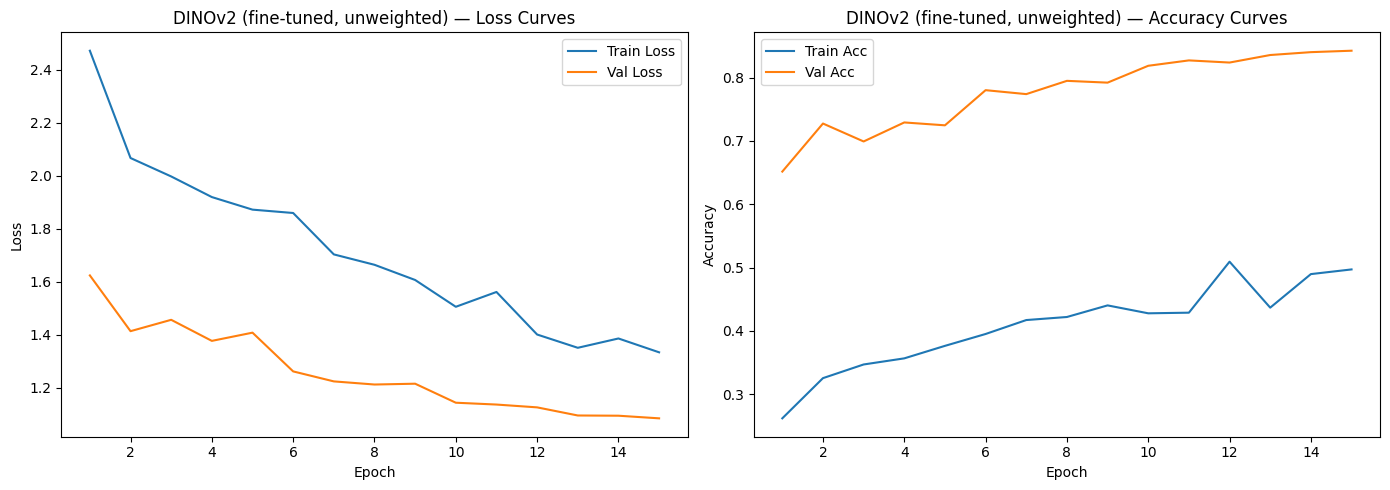

In [ ]:
epochs_range = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(epochs_range, history["train_loss"], label="Train Loss")
axes[0].plot(epochs_range, history["val_loss"], label="Val Loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("DINOv2 (fine-tuned, unweighted) — Loss Curves")
axes[0].legend()

axes[1].plot(epochs_range, history["train_acc"], label="Train Acc")
axes[1].plot(epochs_range, history["val_acc"], label="Val Acc")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].set_title("DINOv2 (fine-tuned, unweighted) — Accuracy Curves")
axes[1].legend()

plt.tight_layout()
plt.savefig("dinov2_training_curves.png", dpi=150)
plt.show()

## Confusion matrix

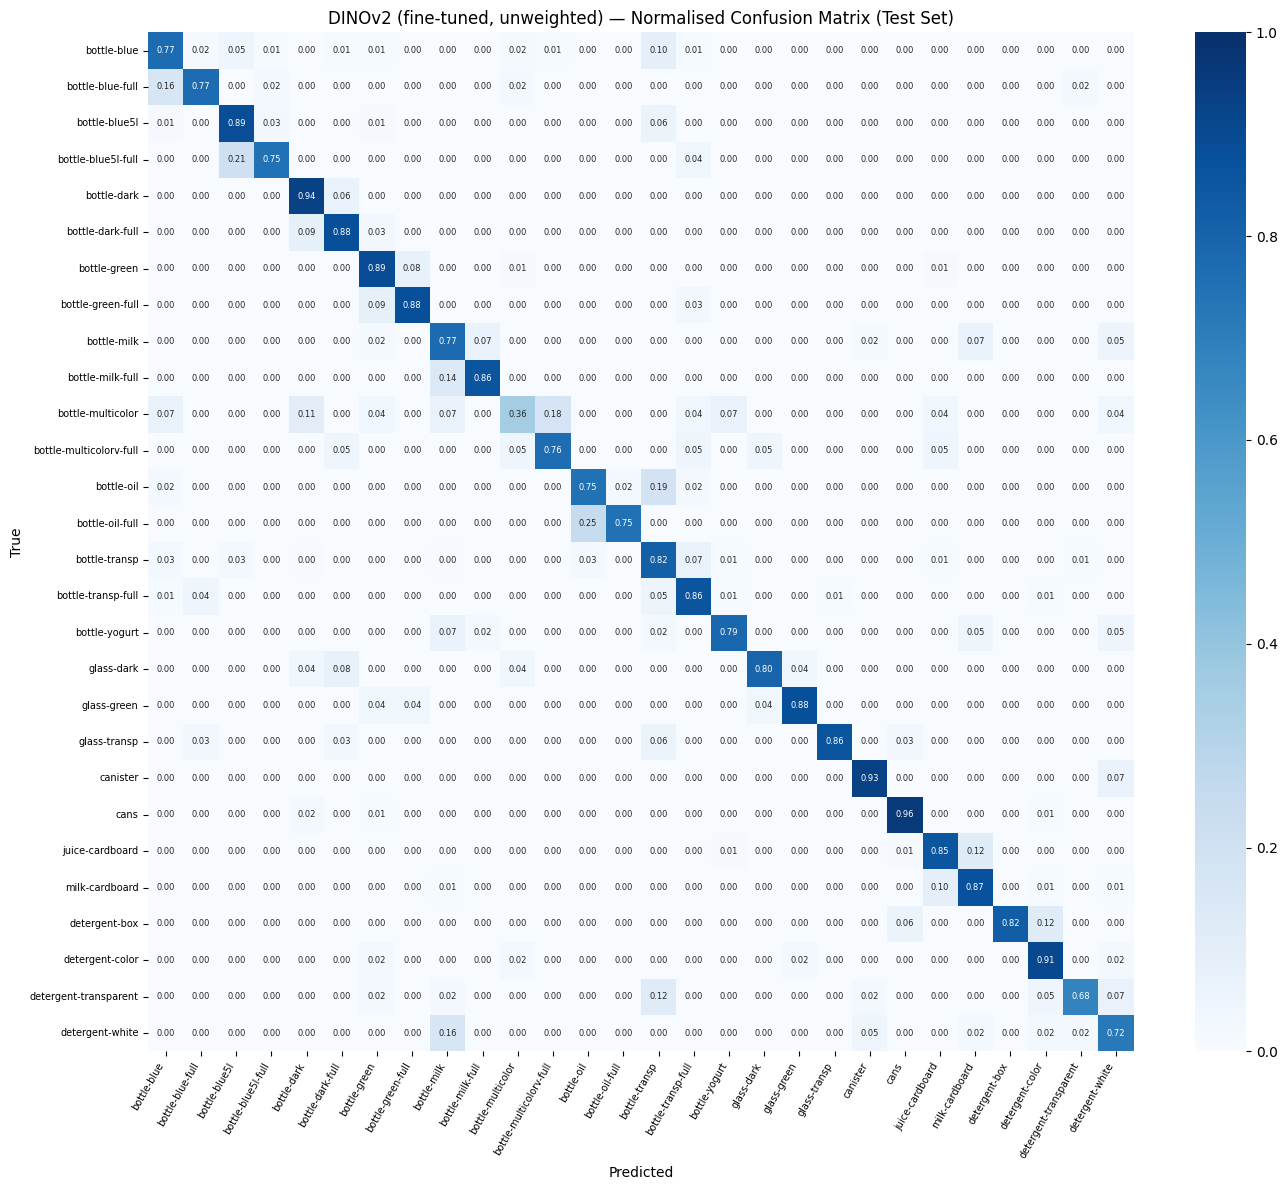

In [ ]:
cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-6)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    cm_norm, annot=True, fmt=".2f",
    xticklabels=class_names, yticklabels=class_names,
    cmap="Blues", vmin=0, vmax=1, ax=ax, annot_kws={"size": 6}
)
ax.set_xlabel("Predicted", fontsize=10)
ax.set_ylabel("True", fontsize=10)
ax.set_title("DINOv2 (fine-tuned, unweighted) — Normalised Confusion Matrix (Test Set)", fontsize=12)
plt.xticks(rotation=60, ha="right", fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.savefig("dinov2_confusion_matrix.png", dpi=150)
plt.show()

## Per-class F1 Chart

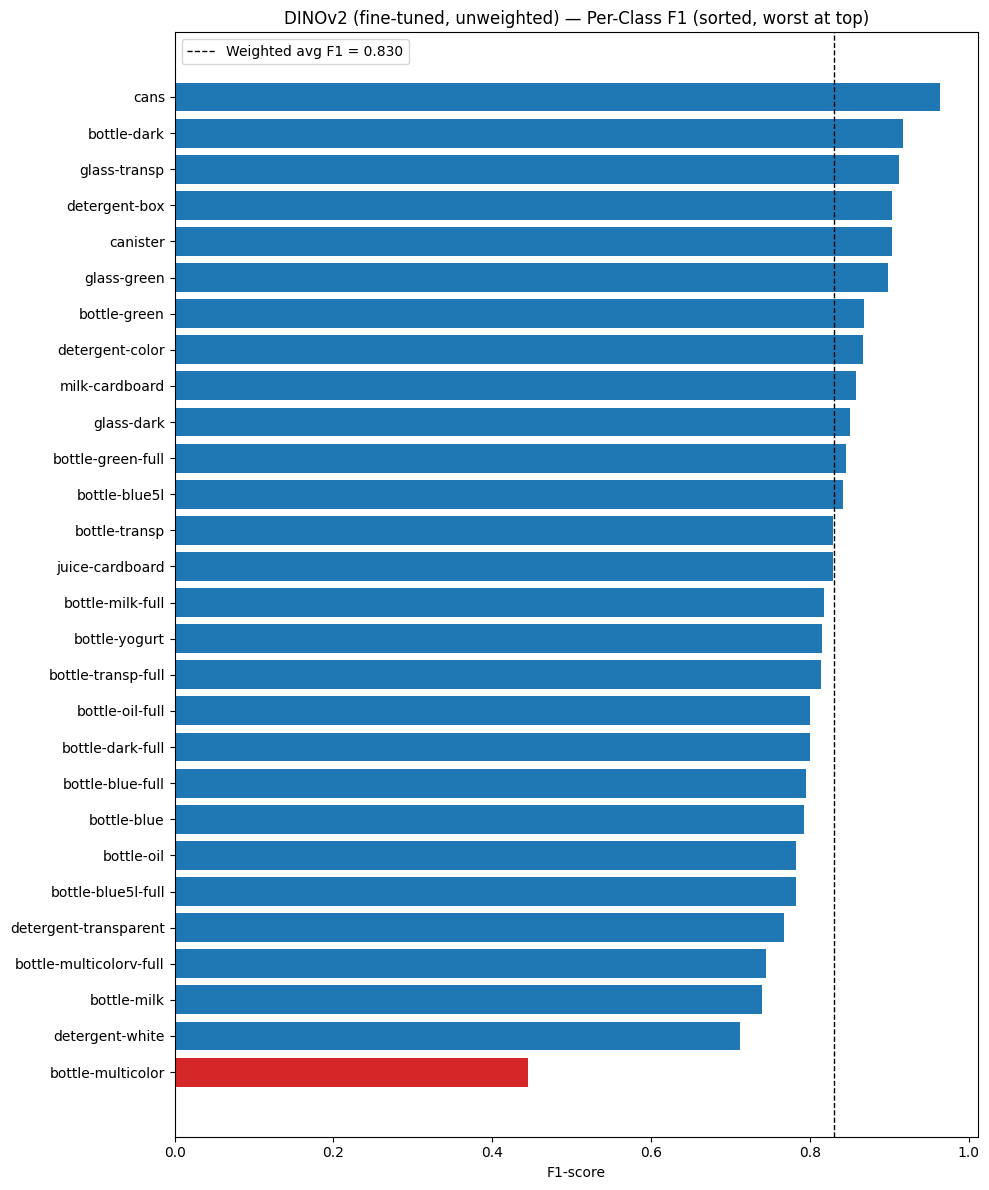

In [ ]:
_, _, per_class_f1, support = precision_recall_fscore_support(
    test_labels, test_preds, average=None, zero_division=0, labels=range(num_classes)
)

order = np.argsort(per_class_f1)
sorted_names = [class_names[i] for i in order]
sorted_f1 = per_class_f1[order]

fig, ax = plt.subplots(figsize=(10, 12))
colors = ["#d62728" if v < 0.5 else "#1f77b4" for v in sorted_f1]
ax.barh(sorted_names, sorted_f1, color=colors)
ax.set_xlabel("F1-score")
ax.set_title("DINOv2 (fine-tuned, unweighted) — Per-Class F1 (sorted, worst at top)")
ax.axvline(f1, color="black", linestyle="--", linewidth=1, label=f"Weighted avg F1 = {f1:.3f}")
ax.legend()
plt.tight_layout()
plt.savefig("dinov2_per_class_f1.png", dpi=150)
plt.show()

## Most-confused class pairs

In [ ]:
def top_confused_pairs(cm, class_names, top_k=10):
    cm_copy = cm.copy().astype(float)
    np.fill_diagonal(cm_copy, 0)
    flat_idx = np.argsort(cm_copy.flatten())[::-1][:top_k]
    pairs = []
    for idx in flat_idx:
        i, j = np.unravel_index(idx, cm_copy.shape)
        if cm_copy[i, j] > 0:
            pairs.append((class_names[i], class_names[j], int(cm_copy[i, j])))
    return pairs

confused_pairs = top_confused_pairs(cm, class_names)
print("Top 10 most-confused (true -> predicted) class pairs:\n")
for true_cls, pred_cls, count in confused_pairs:
    print(f"  {true_cls:25s} -> {pred_cls:25s} : {count} times")

Top 10 most-confused (true -> predicted) class pairs:

  bottle-transp             -> bottle-transp-full        : 17 times
  bottle-blue               -> bottle-transp             : 10 times
  milk-cardboard            -> juice-cardboard           : 9 times
  bottle-oil                -> bottle-transp             : 9 times
  juice-cardboard           -> milk-cardboard            : 8 times
  bottle-blue-full          -> bottle-blue               : 7 times
  detergent-white           -> bottle-milk               : 7 times
  bottle-transp             -> bottle-oil                : 6 times
  bottle-transp             -> bottle-blue5l             : 6 times
  bottle-green              -> bottle-green-full         : 6 times


## Grad-CAM on misclassified examples



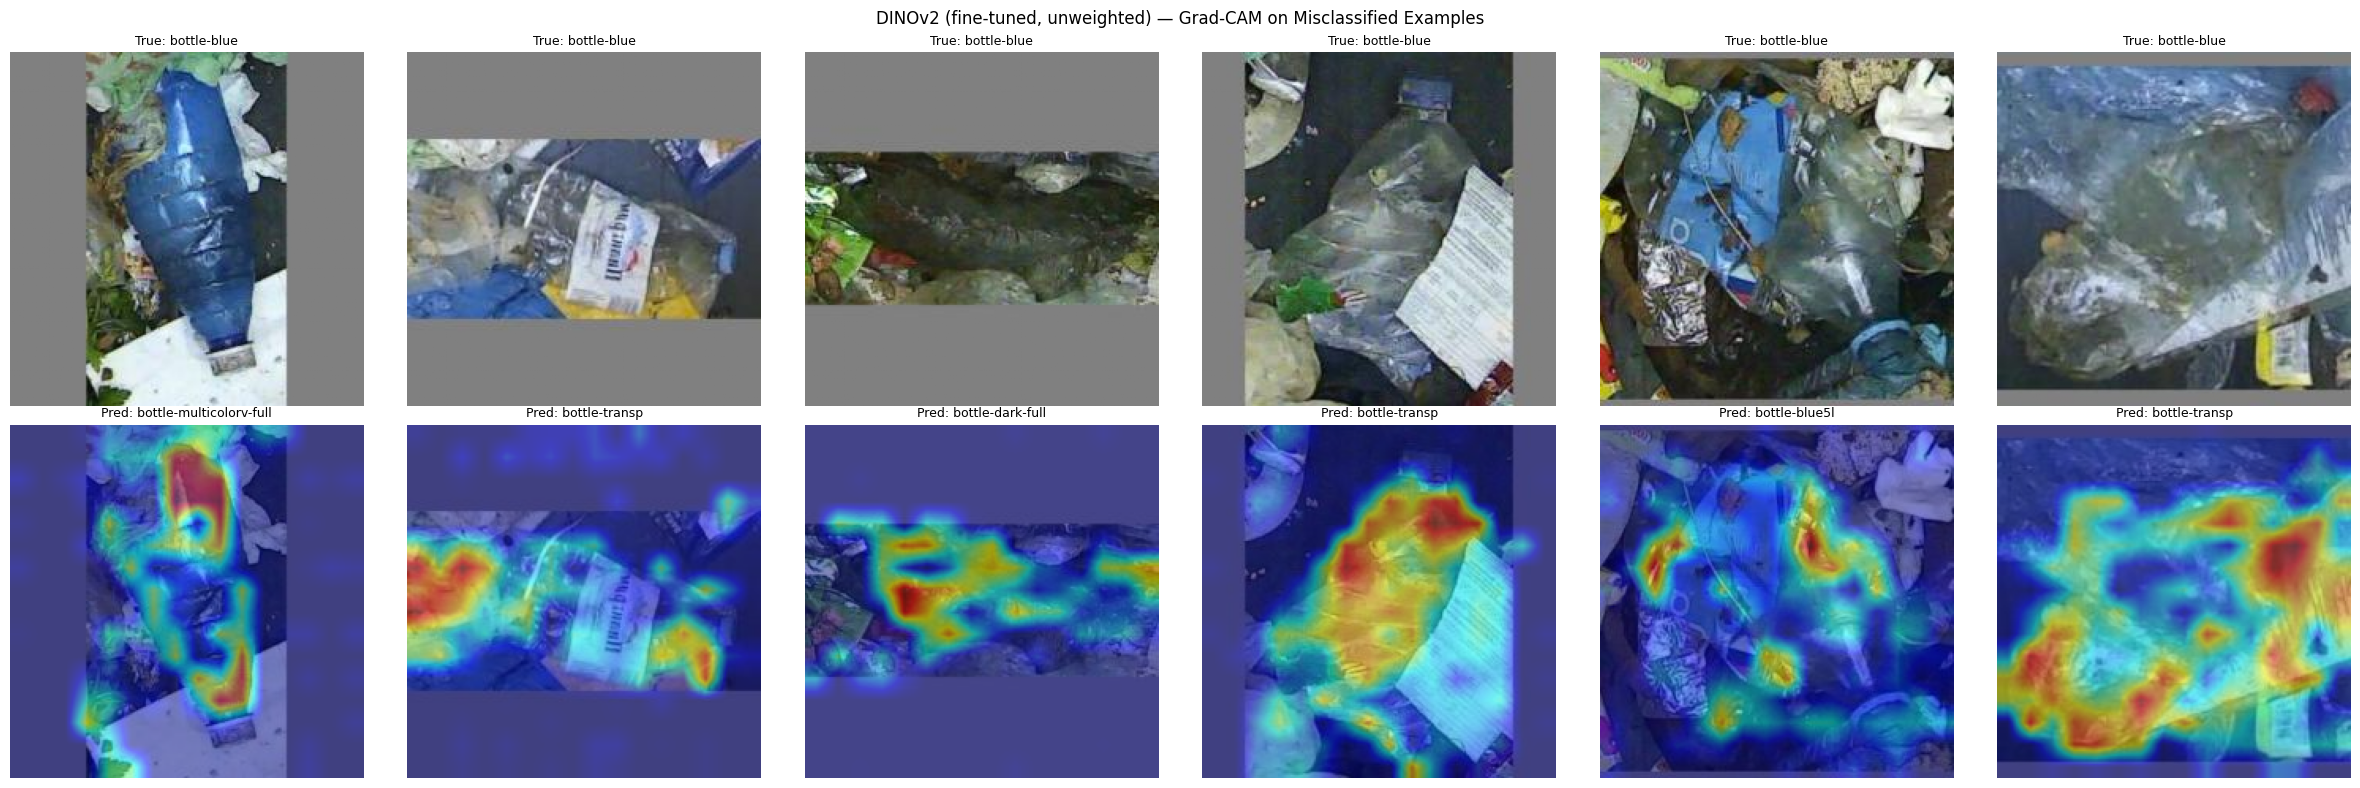

In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from PIL import Image

PATCH_SIZE = 14
IMG_SIZE = 224
GRID_SIZE = IMG_SIZE // PATCH_SIZE

def vit_reshape_transform(tensor, height=GRID_SIZE, width=GRID_SIZE):
    result = tensor[:, 1:, :].reshape(tensor.size(0), height, width, tensor.size(2))
    result = result.transpose(2, 3).transpose(1, 2)
    return result

target_layer = model.backbone.blocks[-1].norm1
cam = GradCAM(model=model, target_layers=[target_layer], reshape_transform=vit_reshape_transform)

misclassified_idx = [i for i, (p, l) in enumerate(zip(test_preds, test_labels)) if p != l][:6]

fig, axes = plt.subplots(2, len(misclassified_idx), figsize=(4 * len(misclassified_idx), 8))

for col, idx in enumerate(misclassified_idx):
    img_path, _ = test_ds.samples[idx]
    raw_img = Image.open(img_path).convert("RGB").resize((224, 224))
    img_np = np.array(raw_img) / 255.0

    input_tensor = eval_pipeline(raw_img).unsqueeze(0).to(device)
    grayscale_cam = cam(input_tensor=input_tensor)[0]
    cam_overlay = show_cam_on_image(img_np.astype(np.float32), grayscale_cam, use_rgb=True)

    axes[0, col].imshow(img_np)
    axes[0, col].set_title(f"True: {class_names[test_labels[idx]]}", fontsize=9)
    axes[0, col].axis("off")

    axes[1, col].imshow(cam_overlay)
    axes[1, col].set_title(f"Pred: {class_names[test_preds[idx]]}", fontsize=9)
    axes[1, col].axis("off")

plt.suptitle("DINOv2 (fine-tuned, unweighted) — Grad-CAM on Misclassified Examples", fontsize=12)
plt.tight_layout()
plt.savefig("dinov2_gradcam_misclassified.png", dpi=150)
plt.show()

In [ ]:
final_results = {
    "config": {"freeze_backbone": CFG["freeze_backbone"], "use_class_weights": CFG["use_class_weights"]},
    "test_acc": float(test_acc),
    "precision": float(precision),
    "recall": float(recall),
    "f1": float(f1),
    "history": history,
    "top_confused_pairs": confused_pairs,
    "per_class_f1": {class_names[i]: float(per_class_f1[i]) for i in range(num_classes)},
}

with open(f"{CONFIG_NAME}_results.json", "w") as f:
    json.dump(final_results, f, indent=2)

np.savez(f"{CONFIG_NAME}_test_predictions.npz",
         preds=np.array(test_preds), labels=np.array(test_labels),
         class_names=np.array(class_names))

torch.save(model.state_dict(), f"{CONFIG_NAME}_final.pth")

from google.colab import files
files.download(f"{CONFIG_NAME}_results.json")
files.download(f"{CONFIG_NAME}_test_predictions.npz")
files.download(f"{CONFIG_NAME}_final.pth")
files.download("dinov2_training_curves.png")
files.download("dinov2_confusion_matrix.png")
files.download("dinov2_per_class_f1.png")
files.download("dinov2_gradcam_misclassified.png")



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## Post-training INT8 quantization



In [ ]:
import torch.quantization
import copy

fp32_model_cpu = copy.deepcopy(model).to("cpu").eval()
quantized_model = torch.quantization.quantize_dynamic(fp32_model_cpu, {nn.Linear}, dtype=torch.qint8)

def get_model_size_mb(m, filename="temp_model.pth"):
    torch.save(m.state_dict(), filename)
    size_mb = os.path.getsize(filename) / (1024 * 1024)
    os.remove(filename)
    return size_mb

fp32_size = get_model_size_mb(fp32_model_cpu)
int8_size = get_model_size_mb(quantized_model)
print(f"FP32 model size : {fp32_size:.2f} MB")
print(f"INT8 model size : {int8_size:.2f} MB")
print(f"Compression     : {fp32_size / int8_size:.2f}x smaller")

/tmp/ipykernel_1250/3516009234.py:5: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quantized_model = torch.quantization.quantize_dynamic(fp32_model_cpu, {nn.Linear}, dtype=torch.qint8)


FP32 model size : 330.42 MB
INT8 model size : 87.40 MB
Compression     : 3.78x smaller


In [ ]:
# Accuracy comparison
cpu = torch.device("cpu")

fp32_loss, fp32_acc, fp32_preds, fp32_labels = evaluate(fp32_model_cpu, test_loader, criterion, eval_device=cpu)
fp32_prec, fp32_rec, fp32_f1, _ = precision_recall_fscore_support(fp32_labels, fp32_preds, average="weighted", zero_division=0)

int8_loss, int8_acc, int8_preds, int8_labels = evaluate(quantized_model, test_loader, criterion, eval_device=cpu)
int8_prec, int8_rec, int8_f1, _ = precision_recall_fscore_support(int8_labels, int8_preds, average="weighted", zero_division=0)

print(f"FP32 (CPU) - Acc: {fp32_acc:.4f} | Prec: {fp32_prec:.4f} | Rec: {fp32_rec:.4f} | F1: {fp32_f1:.4f}")
print(f"INT8 (CPU) - Acc: {int8_acc:.4f} | Prec: {int8_prec:.4f} | Rec: {int8_rec:.4f} | F1: {int8_f1:.4f}")
print(f"Accuracy delta: {(int8_acc - fp32_acc) * 100:+.2f} percentage points")

fp32_cm = confusion_matrix(fp32_labels, fp32_preds)
int8_cm = confusion_matrix(int8_labels, int8_preds)

FP32 (CPU) - Acc: 0.8317 | Prec: 0.8326 | Rec: 0.8317 | F1: 0.8302
INT8 (CPU) - Acc: 0.7034 | Prec: 0.7670 | Rec: 0.7034 | F1: 0.6909
Accuracy delta: -12.83 percentage points


In [ ]:
#Inference latency comparison
def measure_latency(m, input_size=(1, 3, 224, 224), n_runs=50, warmup=5):
    m.eval()
    dummy_input = torch.randn(input_size)
    with torch.no_grad():
        for _ in range(warmup):
            _ = m(dummy_input)
        start = time.time()
        for _ in range(n_runs):
            _ = m(dummy_input)
        elapsed = time.time() - start
    return (elapsed / n_runs) * 1000

fp32_latency_ms = measure_latency(fp32_model_cpu)
int8_latency_ms = measure_latency(quantized_model)
print(f"FP32 CPU latency : {fp32_latency_ms:.2f} ms/image")
print(f"INT8 CPU latency : {int8_latency_ms:.2f} ms/image")


FP32 CPU latency : 601.69 ms/image
INT8 CPU latency : 410.55 ms/image


In [ ]:
quant_results = {
    "fp32_size_mb": fp32_size, "int8_size_mb": int8_size,
    "compression_ratio": fp32_size / int8_size,
    "fp32_acc": fp32_acc, "int8_acc": int8_acc,
    "fp32_f1": fp32_f1, "int8_f1": int8_f1,
    "fp32_latency_ms": fp32_latency_ms, "int8_latency_ms": int8_latency_ms,
    "speedup": fp32_latency_ms / int8_latency_ms,
}

with open("dinov2_quantization_results.json", "w") as f:
    json.dump(quant_results, f, indent=2)

torch.save(quantized_model.state_dict(), "dinov2_int8.pth")

files.download("dinov2_quantization_results.json")
files.download("dinov2_int8.pth")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Classify  uploaded image



Upload an image of any waste item below.



Saving download.png to download (4).png


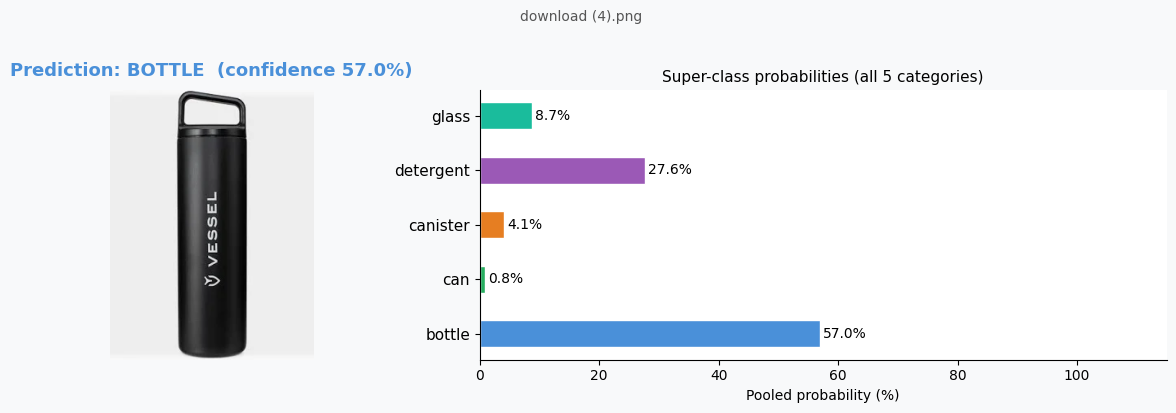


RESULT = BOTTLE


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from PIL import Image, ImageOps
import torch.nn.functional as F
import io

SUPER_CLASSES = ['bottle', 'can', 'canister', 'detergent', 'glass']
CONFIDENCE_THRESHOLD = 0.15

SUPER_CLASS_COLORS = {
    'bottle':    '#4A90D9',
    'can':       '#27AE60',
    'canister':  '#E67E22',
    'detergent': '#9B59B6',
    'glass':     '#1ABC9C',
    'other':     '#95A5A6',
}

def assign_super_class(cls_name: str) -> str:
    name = cls_name.lower()
    if name.startswith('bottle'):    return 'bottle'
    if name in ('cans', 'can'):      return 'can'
    if name == 'canister':           return 'canister'
    if name.startswith('detergent'): return 'detergent'
    if name.startswith('glass'):     return 'glass'
    return 'other'


super_class_indices = {sc: [] for sc in SUPER_CLASSES + ['other']}
for idx, name in enumerate(class_names):
    super_class_indices[assign_super_class(name)].append(idx)

def pad_to_square(img):
    w, h = img.size
    d = max(w, h)
    pl, pt = (d - w) // 2, (d - h) // 2
    return ImageOps.expand(img, (pl, pt, d - w - pl, d - h - pt), fill=(128, 128, 128))

def predict_super_class(pil_image: Image.Image):

    img_processed = pad_to_square(pil_image).resize((224, 224))
    input_tensor = eval_pipeline(img_processed).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        probs = F.softmax(model(input_tensor), dim=1)[0].cpu().numpy()

    # Pool fine-grained probs into super-classes
    pooled = {
        sc: float(probs[super_class_indices[sc]].sum())
        for sc in SUPER_CLASSES + ['other']
    }

    best_sc = max(SUPER_CLASSES, key=lambda sc: pooled[sc])
    if pooled[best_sc] < CONFIDENCE_THRESHOLD:
        best_sc = 'other'

    top3 = [(class_names[i], float(probs[i]))
            for i in np.argsort(probs)[::-1][:3]]

    return best_sc, pooled, top3


def visualise_prediction(pil_image, best_sc, pooled, top3, title='Uploaded image'):
    fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(12, 4),
                                          gridspec_kw={'width_ratios': [1, 1.6]})
    fig.patch.set_facecolor('#F8F9FA')

    ax_img.imshow(pil_image)
    ax_img.axis('off')
    colour = SUPER_CLASS_COLORS[best_sc]
    ax_img.set_title(
        f"Prediction: {best_sc.upper()}  "
        f"(confidence {pooled.get(best_sc, 0)*100:.1f}%)",
        fontsize=13, fontweight='bold', color=colour, pad=10
    )

    sc_probs = [pooled[sc] * 100 for sc in SUPER_CLASSES]
    bar_cols = [SUPER_CLASS_COLORS[sc] for sc in SUPER_CLASSES]
    bars = ax_bar.barh(SUPER_CLASSES, sc_probs, color=bar_cols,
                        edgecolor='white', height=0.5)
    for bar, prob in zip(bars, sc_probs):
        ax_bar.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                    f'{prob:.1f}%', va='center', fontsize=10)
    ax_bar.set_xlim(0, 115)
    ax_bar.set_xlabel('Pooled probability (%)', fontsize=10)
    ax_bar.set_title('Super-class probabilities (all 5 categories)', fontsize=11)
    ax_bar.spines[['top', 'right']].set_visible(False)
    ax_bar.tick_params(axis='y', labelsize=11)

    plt.suptitle(title, fontsize=10, color='#555555', y=1.02)
    plt.tight_layout()
    plt.savefig('waste_detector_prediction.png', dpi=150, bbox_inches='tight')
    plt.show()



print('Upload an image of any waste item below.\n')

uploaded = files.upload()

for filename, file_bytes in uploaded.items():
    pil_img = Image.open(io.BytesIO(file_bytes)).convert('RGB')
    best_sc, pooled, top3 = predict_super_class(pil_img)
    visualise_prediction(pil_img, best_sc, pooled, top3, title=filename)
    print(f'\nRESULT = {best_sc.upper()}')

